In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path='/content/drive/MyDrive/OptimizacionIA/opt_ai_marketing_prj/00_recommendation_system/01_processed_data/ecommerce_data.csv'

In [ ]:
df=pd.read_csv(file_path,sep=',')
df.head()

,customer_id,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,discount_pct,delivery_charges,gst,year,month,day_name,week,quarter,efective_discount,invoice_value
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,10.0,6.5,0.10,2019,Jan,Tuesday,1,1,0.1,158.6729
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,10.0,6.5,0.10,2019,Jan,Tuesday,1,1,0.1,158.6729
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,...,10.0,6.5,0.10,2019,Jan,Tuesday,1,1,0.1,8.5295
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,...,10.0,6.5,0.18,2019,Jan,Tuesday,1,1,0.0,109.9270
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,...,10.0,6.5,0.18,2019,Jan,Tuesday,1,1,0.1,24.0230


# **RFM Customer Segmentation**

RFM Segmentation Analysis is a data-driven customer segmentation technique used by businesses to understand and categorize their customers based on their past purchasing behavior.

This method aims to segment customers based on three essential components of their past purchasing behavior:

* Recency (R): The time since their last purchase.

* Frequency (F): The total number of times they’ve purchased in the past.

* Monetary (M): The total amount they’ve spent.

<br>

<br>

[Understanding RFM Segmentation and K-Means Clustering for Effective Marketing
Strategy](https://medium.com/@radhityan/understanding-rfm-analysis-for-effective-marketing-c21bc1e3b6bb)

[Customer Segmentation RFM Analysis (Recency/Frequency/Monetary)](https://medium.com/@hhuseyincosgun/customer-segmentation-rfm-analysis-recency-frequency-monetary-5b29d5d45e35)

[RFM Customer Segmentation Analysis In Action!](https://justdataplease.medium.com/rfm-customer-segmentation-analysis-in-action-9108c906c628)

## **Cálculo de Recency, Frequency, Monetary**

Además se consideró el cálculo de las cantidades compradas por cada usuario (**Quantity**)

In [ ]:
df['transaction_date']=pd.to_datetime(df['transaction_date'], format='%Y-%m-%d')

In [ ]:
recency=df.groupby(['customer_id'])['transaction_date'].max().reset_index()
recency.columns=['customer_id','max_transaction_date']
recency.head()

,customer_id,max_transaction_date
0,12346,2019-09-15
1,12347,2019-11-02
2,12348,2019-10-19
3,12350,2019-12-14
4,12356,2019-09-15


In [ ]:
fecha_corte=pd.to_datetime('2020-01-01')
recency['recency_days']=fecha_corte-recency['max_transaction_date']
recency.head()

,customer_id,max_transaction_date,recency_days
0,12346,2019-09-15,108 days
1,12347,2019-11-02,60 days
2,12348,2019-10-19,74 days
3,12350,2019-12-14,18 days
4,12356,2019-09-15,108 days


In [ ]:
df_trans = df.groupby(['customer_id','transaction_id'], as_index=False).agg({
    'invoice_value':'sum',
    'quantity':'sum',
    'transaction_date':'max'
})
df_trans.columns=['customer_id','transaction_id','invoice_value','quantity','transaction_date']
df_trans.head()

,customer_id,transaction_id,invoice_value,quantity,transaction_date
0,12346,38223,174.98174,3,2019-09-15
1,12347,23979,39.80130,2,2019-03-24
2,12347,23980,562.23000,6,2019-03-24
3,12347,23981,361.30920,23,2019-03-24
4,12347,23984,9875.95852,217,2019-03-24


In [ ]:
df_rfm = df_trans.groupby('customer_id', as_index=False).agg(
    last_purchase_date = ('transaction_date', 'max'),
    frequency = ('transaction_id', 'count'),
    monetary = ('invoice_value', 'sum'),
    quantity = ('quantity', 'sum'),
)
df_rfm['recency'] = (fecha_corte - df_rfm['last_purchase_date']).dt.days
df_rfm.head()

,customer_id,last_purchase_date,frequency,monetary,quantity,recency
0,12346,2019-09-15,1,174.98174,3,108
1,12347,2019-11-02,31,15686.84396,342,60
2,12348,2019-10-19,8,1689.55594,209,74
3,12350,2019-12-14,11,1467.43528,21,18
4,12356,2019-09-15,13,2007.42900,56,108


In [ ]:
df[df.customer_id==12347]

,customer_id,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,discount_pct,delivery_charges,gst,year,month,day_name,week,quarter,efective_discount,invoice_value
10667,12347,M,New York,20,23979,2019-03-24,GGOEGOAQ020099,Four Color Retractable Pen,Office,1,...,30.0,14.41,0.10,2019,Mar,Sunday,12,1,0.0,17.69900
10668,12347,M,New York,20,23979,2019-03-24,GGOEGOCT019199,Red Spiral Google Notebook,Office,1,...,30.0,14.41,0.10,2019,Mar,Sunday,12,1,0.3,22.10230
10669,12347,M,New York,20,23980,2019-03-24,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,30.0,6.50,0.10,2019,Mar,Sunday,12,1,0.3,121.23000
10670,12347,M,New York,20,23980,2019-03-24,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,...,30.0,6.50,0.10,2019,Mar,Sunday,12,1,0.0,441.00000
10671,12347,M,New York,20,23981,2019-03-24,GGOEGBFC018799,Electronics Accessory Pouch,Bags,4,...,30.0,49.73,0.18,2019,Mar,Sunday,12,1,0.0,73.28280
10672,12347,M,New York,20,23981,2019-03-24,GGOEGFKA022299,Keyboard DOT Sticker,Office,10,...,30.0,49.73,0.10,2019,Mar,Sunday,12,1,0.3,61.28000
10673,12347,M,New York,20,23981,2019-03-24,GGOEGFYQ016599,Foam Can and Bottle Cooler,Drinkware,4,...,30.0,49.73,0.18,2019,Mar,Sunday,12,1,0.0,59.12280
10674,12347,M,New York,20,23981,2019-03-24,GGOEGHPB080410,Google 5-Panel Snapback Cap,Headgear,2,...,30.0,49.73,0.05,2019,Mar,Sunday,12,1,0.0,89.60900
10675,12347,M,New York,20,23981,2019-03-24,GGOEYDHJ019399,24 oz YouTube Sergeant Stripe Bottle,Drinkware,3,...,30.0,49.73,0.18,2019,Mar,Sunday,12,1,0.0,78.01460
10676,12347,M,New York,20,23984,2019-03-24,GGOEGAEL031113,Google Men's Heavyweight Long Sleeve Hero Tee ...,Apparel,55,...,30.0,6.50,0.18,2019,Mar,Sunday,12,1,0.0,2601.85100


### **Cálculo de purchase_days**

La variable frequency solo refleja cuántas veces compró un cliente, pero se encontró que un cliente puede realizar varias compras en un solo día. Por ejemplo, un usuario puede registrar 20 trasanction_id sólo en dos días de 365, por lo que su frecuencia en días de compra fue muy baja, esto también se puede ver influenciado en el recency.

Por lo tanto, se determinó cuántos días del año el cliente realizó una compra.

In [ ]:
purchase_days_df=df.groupby('customer_id', as_index=False)['transaction_date'].nunique()
purchase_days_df.columns=['customer_id','purchase_days']
purchase_days_df.head()

,customer_id,purchase_days
0,12346,1
1,12347,3
2,12348,2
3,12350,1
4,12356,1


In [ ]:
purchase_days_df.describe()

,customer_id,purchase_days
count,1468.000000,1468.000000
mean,15314.386240,2.185286
std,1744.000367,2.235245
min,12346.000000,1.000000
25%,13830.500000,1.000000
50%,15300.000000,1.500000
75%,16882.250000,3.000000
max,18283.000000,34.000000


In [ ]:
df_rfm=df_rfm.merge(purchase_days_df, on='customer_id', how='left')
df_rfm.head()

,customer_id,last_purchase_date,frequency,monetary,quantity,recency,purchase_days
0,12346,2019-09-15,1,174.98174,3,108,1
1,12347,2019-11-02,31,15686.84396,342,60,3
2,12348,2019-10-19,8,1689.55594,209,74,2
3,12350,2019-12-14,11,1467.43528,21,18,1
4,12356,2019-09-15,13,2007.42900,56,108,1


In [ ]:
features=['recency','purchase_days','frequency','monetary','quantity']
features2=['purchase_days','frequency','monetary', 'quantity']
df_rfm[features].describe()

,recency,purchase_days,frequency,monetary,quantity
count,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000
mean,145.292234,2.185286,18.141008,3668.589235,162.147820
std,101.936959,2.235245,24.976414,5818.854233,312.374078
min,1.000000,1.000000,1.000000,6.990000,1.000000
25%,56.000000,1.000000,5.000000,783.068420,19.000000
50%,132.000000,1.500000,11.000000,2007.505370,61.000000
75%,221.000000,3.000000,23.000000,4495.056630,178.000000
max,365.000000,34.000000,328.000000,86901.495440,4869.000000


## **Segmentation models**

### **Data preparation**

In [ ]:
data=df_rfm.copy()

X=data[features]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

### **Prueba de KMeans**

In [ ]:
clusters=3
kmeans = KMeans(n_clusters=clusters, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_
data['kmeans_segm'] = labels

In [ ]:
df_clusters = data.groupby('kmeans_segm').agg({
    'customer_id':'count',
    'recency':'mean',
    'purchase_days':'mean',
    'frequency':'mean',
    'monetary':'mean',
    'quantity':'mean'
}).reset_index()

df_clusters

,kmeans_segm,customer_id,recency,purchase_days,frequency,monetary,quantity
0,0,1205,159.965145,1.608299,10.752697,2012.162430,83.219087
1,1,258,78.992248,4.414729,47.391473,10113.463404,467.786822
2,2,5,30.200000,26.200000,289.400000,70311.942140,3413.000000


In [ ]:
silhouette_avg = silhouette_score(X_scaled, labels)
print(f'Silhouette Score: {silhouette_avg:.4f}')

Silhouette Score: 0.4675


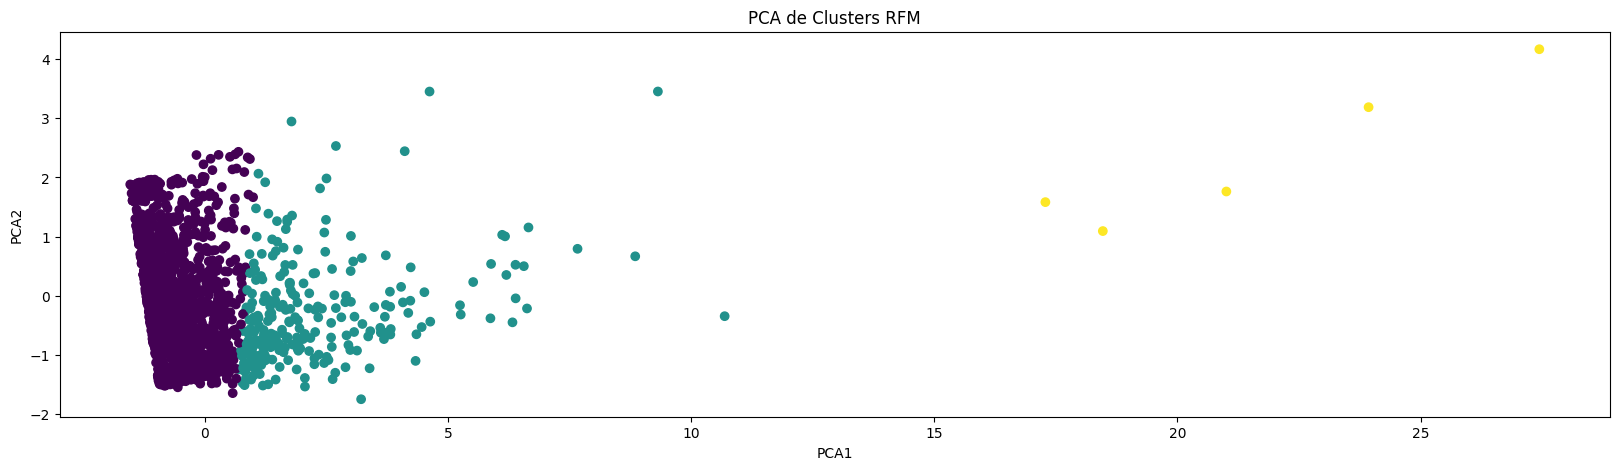

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_fit = pca.fit_transform(X_scaled)
data['pca1'] = pca_fit[:,0]
data['pca2'] = pca_fit[:,1]

plt.figure(figsize=(20,5))
plt.scatter(data['pca1'], data['pca2'], c=data['kmeans_segm'])
plt.title('PCA de Clusters RFM')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

#### **Número óptimo de clusters**

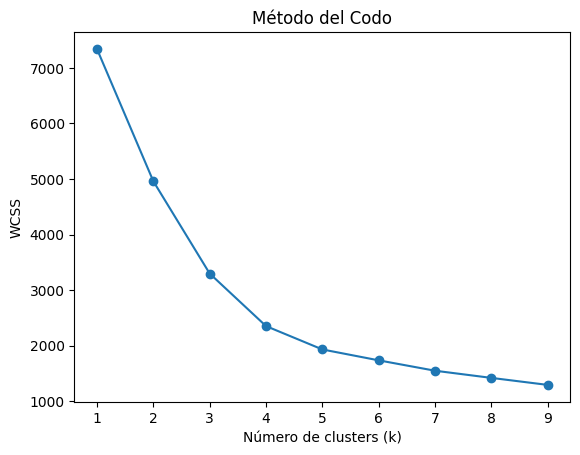

In [ ]:
wcss = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [ ]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    s_score = silhouette_score(X_scaled, labels)
    print(f'k={k}, silhouette={s_score:.4f}')

k=2, silhouette=0.8991
k=3, silhouette=0.4675
k=4, silhouette=0.3554
k=5, silhouette=0.3588
k=6, silhouette=0.2824
k=7, silhouette=0.2944
k=8, silhouette=0.2990
k=9, silhouette=0.3084


#### **Feature Engineering**

Selección de parámetros

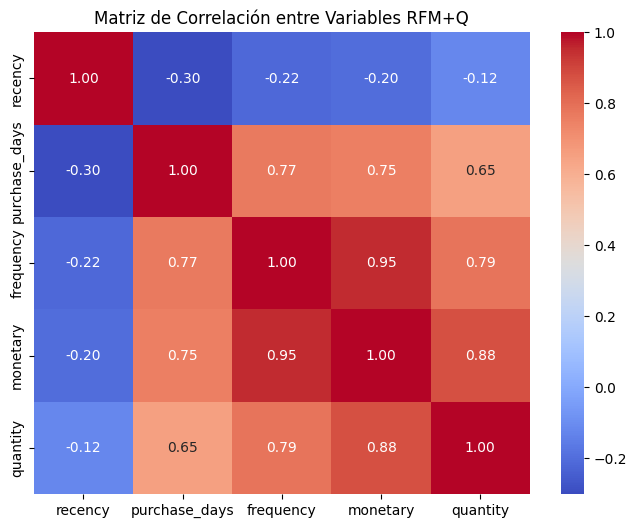

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(X_scaled, columns=['recency', 'purchase_days', 'frequency', 'monetary', 'quantity']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación entre Variables RFM+Q+P")
plt.show()

In [ ]:
pca_full = PCA(n_components=5)
pca_full.fit(X_scaled)

PCA(n_components=5)

In [ ]:
explained_variance = pca_full.explained_variance_ratio_
print(explained_variance)

pca_components = pd.DataFrame(pca_full.components_, columns=features, index=[f'PC{i+1}' for i in range(len(features))])
pca_components

[0.69473395 0.1918756  0.06735605 0.03988728 0.00614711]


,recency,purchase_days,frequency,monetary,quantity
PC1,-0.167448,0.463120,0.510398,0.519747,0.476276
PC2,0.961283,-0.098358,0.082452,0.123928,0.210009
PC3,0.218056,0.814512,-0.001510,-0.194911,-0.501029
PC4,-0.017179,0.333844,-0.625701,-0.280903,0.646409
PC5,0.007215,0.031070,-0.584116,0.773051,-0.245322


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

labels = np.random.randint(0, 4, size=df_rfm.shape[0])

selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X_scaled, labels)

selected_features = np.array(['recency', 'purchase_days', 'frequency', 'monetary', 'quantity'])[selector.get_support()]
selected_features

array(['frequency', 'monetary', 'quantity'], dtype='<U13')

Caracaterísticas a seleccionar: 'frequency', 'monetary', 'quantity'

In [ ]:
feature_scores = selector.scores_

feature_importance_df = pd.DataFrame({'Feature': ['recency', 'purchase_days', 'frequency', 'monetary', 'quantity'],
                                      'Score': feature_scores})

feature_importance_df = feature_importance_df.sort_values(by='Score', ascending=False)
feature_importance_df

,Feature,Score
4,quantity,2.768612
3,monetary,2.056212
2,frequency,1.714683
1,purchase_days,1.531521
0,recency,0.317416


### **KMeans Features Optimized**

In [ ]:
X_opt=data[selected_features]

scaler=StandardScaler()
X_scaled_opt=scaler.fit_transform(X_opt)

clusters=4
kmeans = KMeans(n_clusters=clusters, random_state=42, n_init=10)
kmeans.fit(X_scaled_opt)
labels = kmeans.labels_
data['kmeans_segm_opt'] = labels

In [ ]:
silhouette_avg = silhouette_score(X_scaled_opt, labels)
print(f'Silhouette Score: {silhouette_avg:.4f}')

Silhouette Score: 0.5912


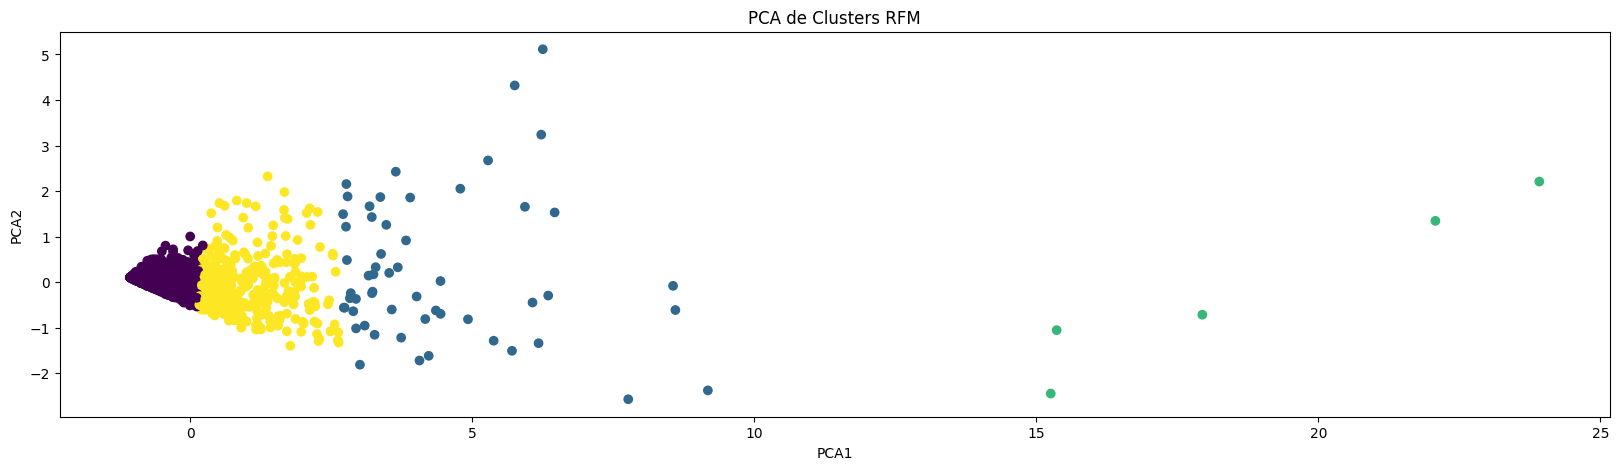

In [ ]:
pca = PCA(n_components=2)
pca_fit = pca.fit_transform(X_scaled_opt)
data['pca1'] = pca_fit[:,0]
data['pca2'] = pca_fit[:,1]

plt.figure(figsize=(20,5))
plt.scatter(data['pca1'], data['pca2'], c=data['kmeans_segm_opt'])
plt.title('PCA de Clusters RFM')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

In [ ]:
df_clusters_opt = data.groupby('kmeans_segm_opt').agg({
    'customer_id':'count',
    'recency':'mean',
    'purchase_days':'mean',
    'frequency':'mean',
    'monetary':'mean',
    'quantity':'mean'
}).reset_index()

df_clusters_opt

,kmeans_segm_opt,customer_id,recency,purchase_days,frequency,monetary,quantity
0,0,1069,155.637044,1.642657,8.710945,1555.284736,57.586529
1,1,56,84.964286,5.625000,77.392857,18035.249262,979.946429
2,2,5,30.200000,26.200000,289.400000,70311.942140,3413.000000
3,3,338,124.272189,2.976331,34.136095,6986.260190,309.263314


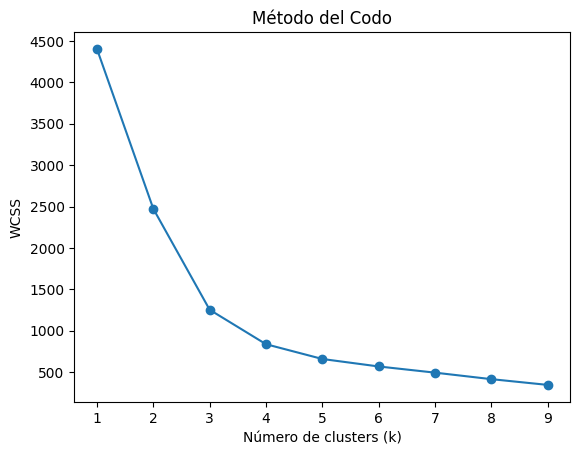

k=2, silhouette=0.7859
k=3, silhouette=0.6833
k=4, silhouette=0.5912
k=5, silhouette=0.5325
k=6, silhouette=0.5228
k=7, silhouette=0.4713
k=8, silhouette=0.4706
k=9, silhouette=0.4711


In [ ]:
wcss = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_opt)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS')
plt.show()

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_opt)
    labels = kmeans.labels_
    s_score = silhouette_score(X_scaled_opt, labels)
    print(f'k={k}, silhouette={s_score:.4f}')

In [ ]:
clusters=3
kmeans = KMeans(n_clusters=clusters, random_state=42, n_init=10)
kmeans.fit(X_scaled_opt)
labels = kmeans.labels_
data['kmeans_segm_opt'] = labels
silhouette_avg = silhouette_score(X_scaled_opt, labels)
print(f'Silhouette Score: {silhouette_avg:.4f}')

Silhouette Score: 0.6833


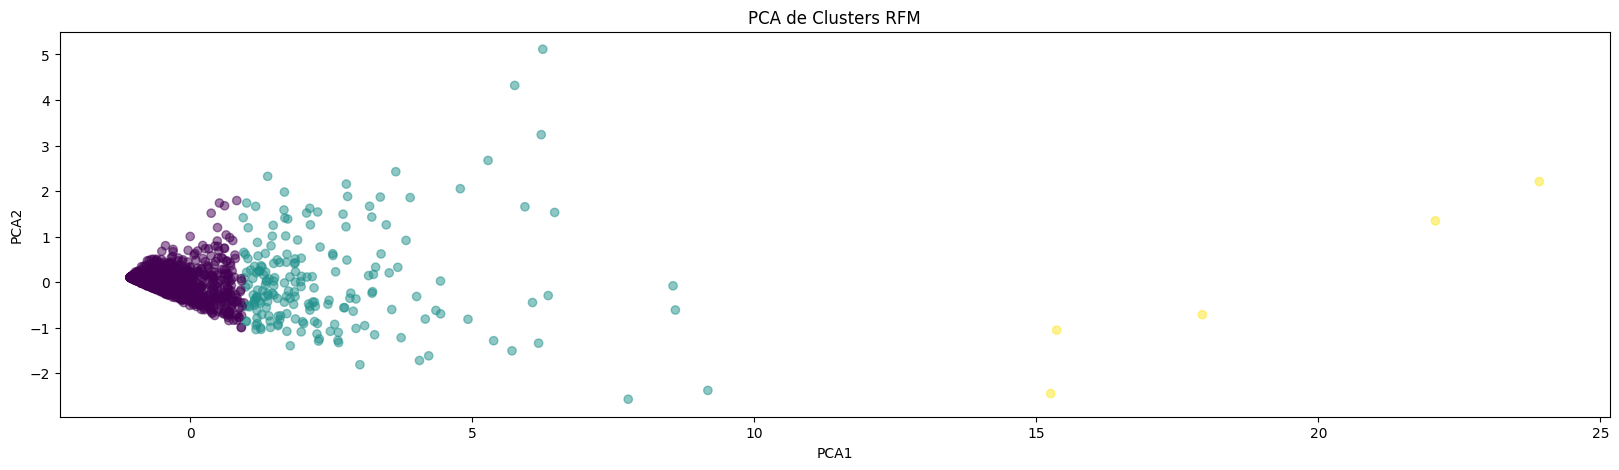

In [ ]:
plt.figure(figsize=(20,5))
plt.scatter(data['pca1'], data['pca2'], c=data['kmeans_segm_opt'], alpha=0.5)
plt.title('PCA de Clusters RFM')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

### **DBSCAN Feat. Opt.**

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5) #0.9
labels = dbscan.fit_predict(X_scaled_opt)

In [ ]:
data['dbscan_segm'] = labels

In [ ]:
sc = silhouette_score(X_scaled_opt, labels)
print("Silhouette Coefficient:%0.2f" % sc)

Silhouette Coefficient:0.89


In [ ]:
data['dbscan_segm'].value_counts()

,count
dbscan_segm,
0,1455
-1,13


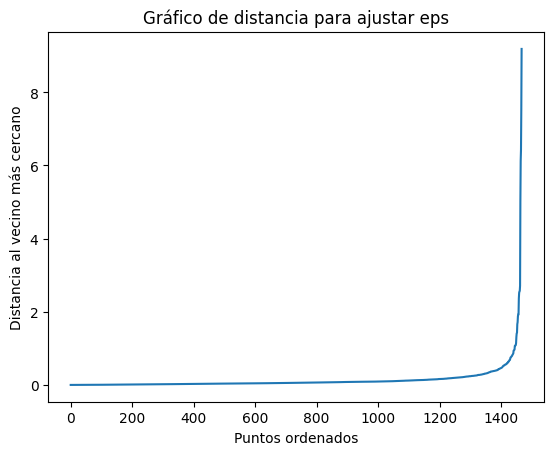

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(X_scaled_opt)
distances, indices = nbrs.kneighbors(X_scaled_opt)

distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al vecino más cercano")
plt.title("Gráfico de distancia para ajustar eps")
plt.show()

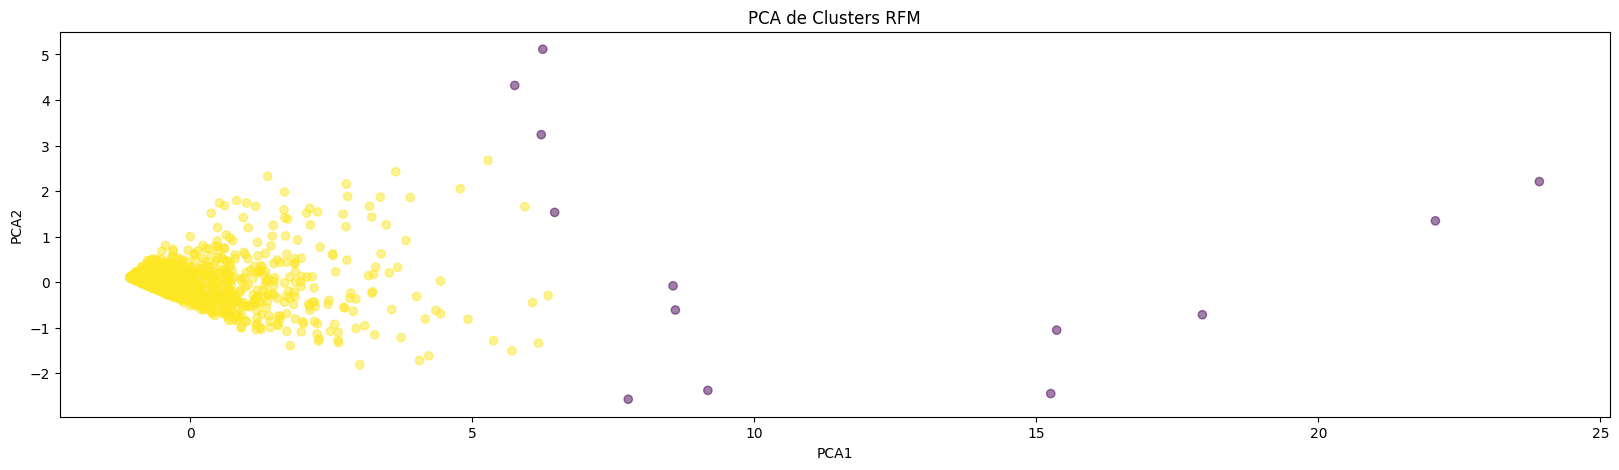

In [ ]:
plt.figure(figsize=(20,5))
plt.scatter(data['pca1'], data['pca2'], c=data['dbscan_segm'], cmap='viridis', alpha=0.5)
plt.title('PCA de Clusters RFM')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

In [ ]:
!pip install scikit-learn-extra -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.8 MB/s eta 0:00:00


### **KMedoids Feat. Opt.**

In [ ]:
from sklearn_extra.cluster import KMedoids

k = 3
kmedoids = KMedoids(n_clusters=k, random_state=42)
labels_kmedoids = kmedoids.fit_predict(X_scaled_opt)

n_clusters_kmedoids = len(np.unique(labels_kmedoids))

data['kmedoids_segm'] = labels_kmedoids

silhouette_kmedoids = silhouette_score(X_scaled_opt, labels_kmedoids)
n_clusters_kmedoids, silhouette_kmedoids

(3, 0.43027973702230676)

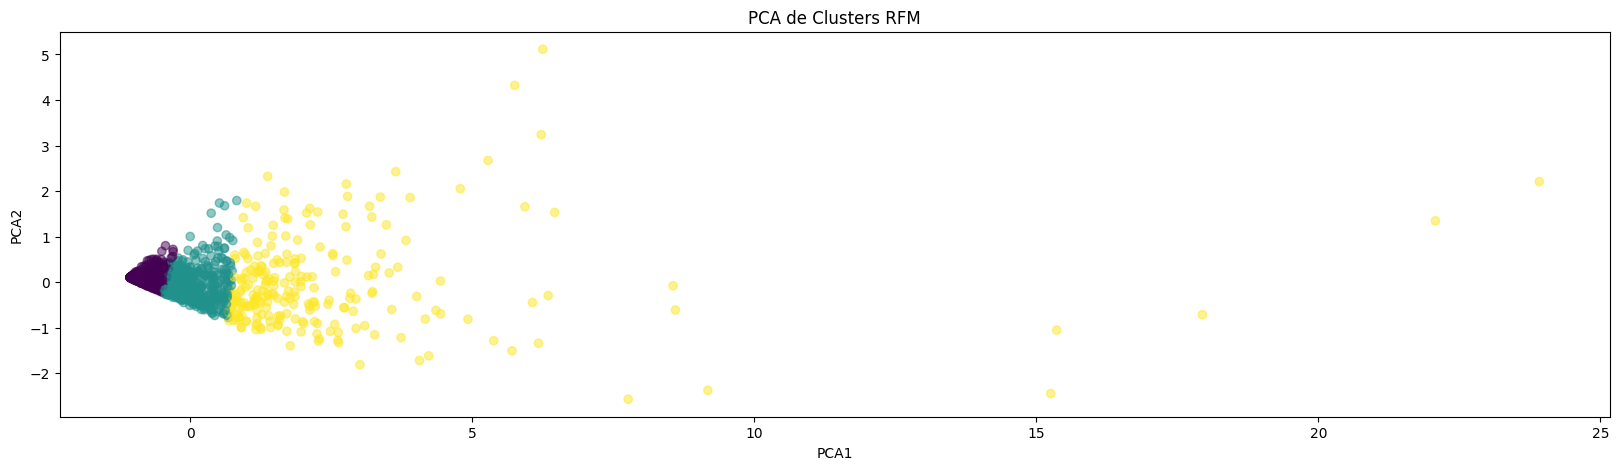

In [ ]:
plt.figure(figsize=(20,5))
plt.scatter(data['pca1'], data['pca2'], c=data['kmedoids_segm'], cmap='viridis', alpha=0.5)
plt.title('PCA de Clusters RFM')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

### **GaussianMixture Feat. Opt**

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

k = 3

gmm = GaussianMixture(n_components=k, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled_opt)

silhouette_gmm = silhouette_score(X_scaled_opt, labels_gmm)

data['gmm_segm'] = labels_gmm

print(f"Número de clusters detectados con GMM: {len(np.unique(labels_gmm))}")
print(f"Silhouette Score para GMM: {silhouette_gmm:.4f}")

Número de clusters detectados con GMM: 3
Silhouette Score para GMM: 0.4651


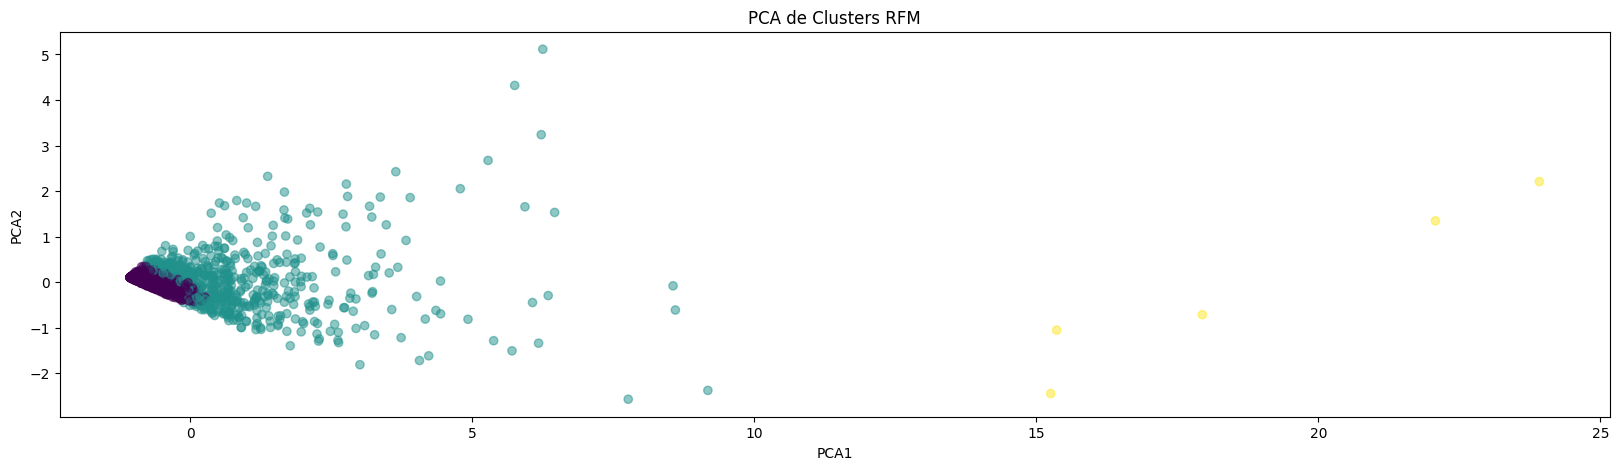

In [ ]:
plt.figure(figsize=(20,5))
plt.scatter(data['pca1'], data['pca2'], c=data['gmm_segm'], cmap='viridis', alpha=0.5)
plt.title('PCA de Clusters RFM')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

### **Deep Learning Autoencoders & KMeans**

Autoencoders are a type of artificial neural network that is used to learn feature representation in an unsupervised manner. It uses the same data for input and output.

[Credit Card Customer Clustering with Autoencoder and K-means](https://medium.com/towards-data-science/credit-card-customer-clustering-with-autoencoder-and-k-means-16654d54e64e)

In [ ]:
import tensorflow as tf
from tensorflow import keras

input_dim = X_scaled_opt.shape[1]
encoding_dim = 3

input_layer = keras.layers.Input(shape=(input_dim,))
encoded = keras.layers.Dense(10, activation='relu')(input_layer)
encoded = keras.layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = keras.layers.Dense(10, activation='relu')(encoded)
decoded = keras.layers.Dense(input_dim, activation='relu')(decoded)

optimizer = keras.optimizers.Adam(learning_rate=1e-4)
autoencoder = keras.Model(input_layer, decoded)
autoencoder.compile(optimizer=optimizer, loss='mse')

early_stopping = keras.callbacks.EarlyStopping(
    monitor='loss', patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    X_scaled_opt, X_scaled_opt,
    epochs=300,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping]
)

encoder = keras.Model(input_layer, encoded)

features_autoencoder = encoder.predict(X_scaled_opt)

Epoch 1/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.4856
Epoch 2/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6162
Epoch 3/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5167
Epoch 4/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5865
Epoch 5/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4498
Epoch 6/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6708
Epoch 7/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5377
Epoch 8/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5298
Epoch 9/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5286
Epoch 10/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4193
Epoch 11/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3720
Epoch 12/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4420
Epoch 13/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3927
Epoch 14/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3028
Epoch 15/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3961
Epoc

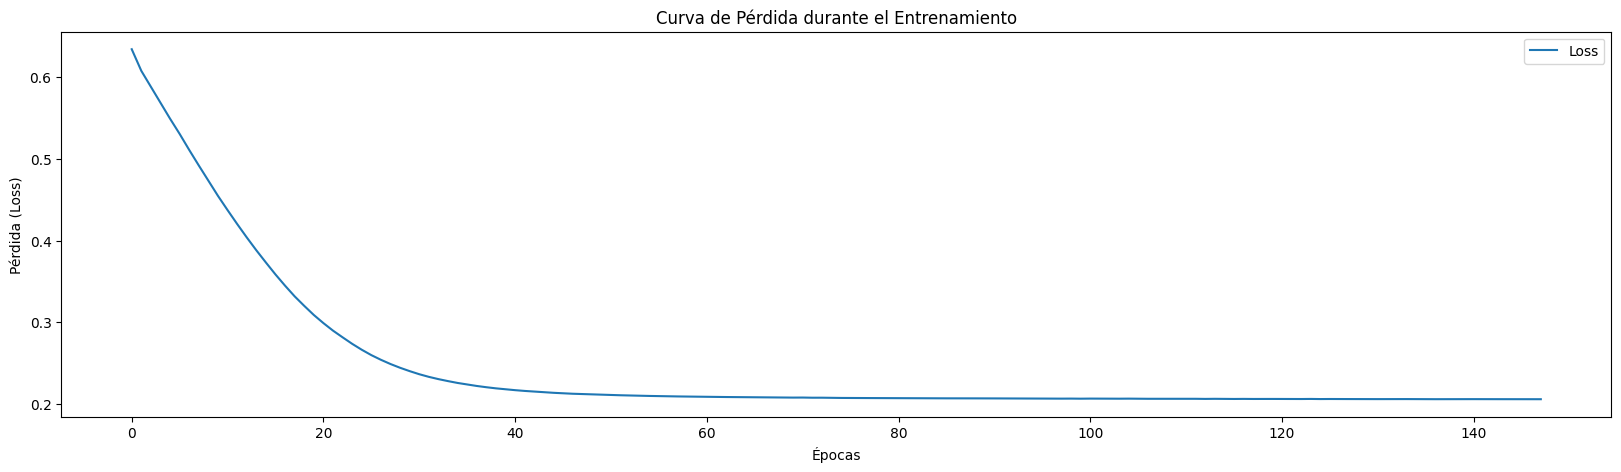

In [ ]:
loss_history = history.history['loss']

plt.figure(figsize=(20, 5))
plt.plot(loss_history, label="Loss")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (Loss)")
plt.title("Curva de Pérdida durante el Entrenamiento")
plt.legend()
plt.show()

In [ ]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels_autoencoder_kmeans = kmeans.fit_predict(features_autoencoder)

silhouette_autoencoder_kmeans = silhouette_score(features_autoencoder, labels_autoencoder_kmeans)

data['autoencoder_kmeans_segm'] = labels_autoencoder_kmeans

n_clusters_autoencoder_kmeans = len(np.unique(labels_autoencoder_kmeans))
n_clusters_autoencoder_kmeans, silhouette_autoencoder_kmeans

(3, 0.8359528)

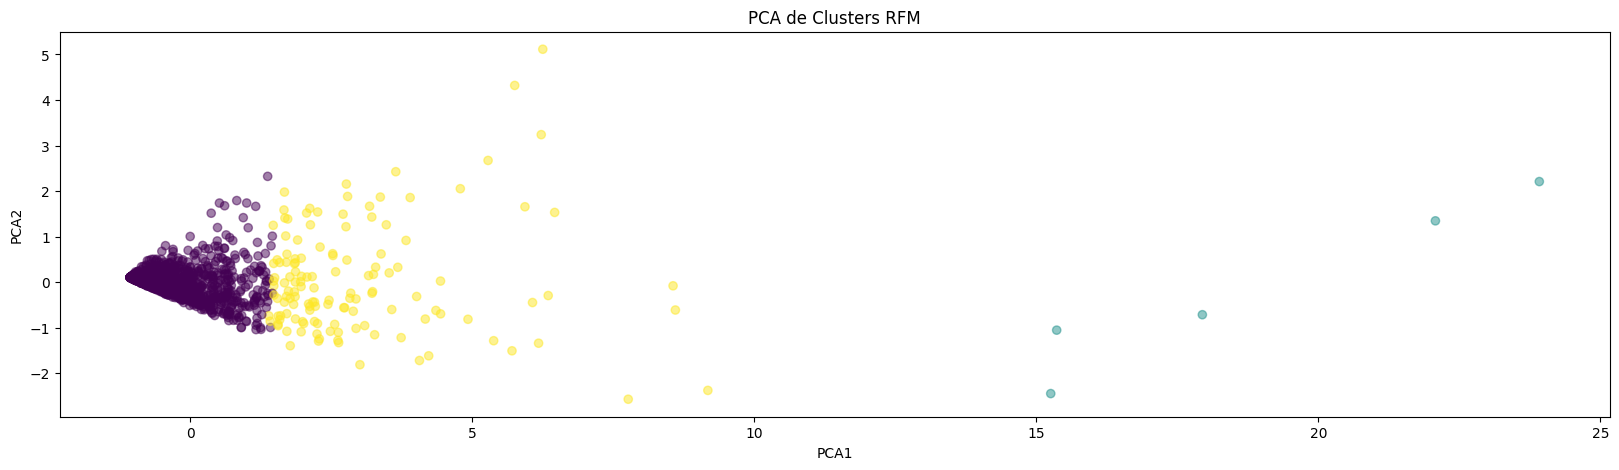

In [ ]:
plt.figure(figsize=(20,5))
plt.scatter(data['pca1'], data['pca2'], c=data['autoencoder_kmeans_segm'], cmap='viridis', alpha=0.5)
plt.title('PCA de Clusters RFM')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

In [ ]:
df_clusters_opt = data.groupby('autoencoder_kmeans_segm').agg({
    'customer_id':'count',
    'recency':'mean',
    'purchase_days':'mean',
    'frequency':'mean',
    'monetary':'mean',
    'quantity':'mean'
}).reset_index()

df_clusters_opt

,autoencoder_kmeans_segm,customer_id,recency,purchase_days,frequency,monetary,quantity
0,0,1329,150.699022,1.869827,12.848006,2426.264804,96.872837
1,1,5,30.200000,26.200000,289.400000,70311.942140,3413.000000
2,2,134,95.962687,4.417910,60.514925,13503.159412,688.238806


In [ ]:
df_clusters_opt = data.groupby('kmeans_segm_opt').agg({
    'customer_id':'count',
    'recency':'mean',
    'purchase_days':'mean',
    'frequency':'mean',
    'monetary':'mean',
    'quantity':'mean'
}).reset_index()

df_clusters_opt

,kmeans_segm_opt,customer_id,recency,purchase_days,frequency,monetary,quantity
0,0,1265,151.376285,1.813439,11.662451,2164.541054,82.973123
1,1,198,109.328283,3.954545,52.681818,11594.872996,585.893939
2,2,5,30.200000,26.200000,289.400000,70311.942140,3413.000000


In [ ]:
customers_segmented = data.drop_duplicates(subset='customer_id',keep='first')
customers_segmented = customers_segmented[[
    'customer_id',
    'kmeans_segm',
    'kmeans_segm_opt',
    #'dbscan_segm',
    #'kmedoids_segm',
    #'gmm_segm',
    'autoencoder_kmeans_segm'
]]
customers_segmented.autoencoder_kmeans_segm.replace({1:2, 2:1}, inplace=True)

<ipython-input-101-e898575a0ad1>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers_segmented.autoencoder_kmeans_segm.replace({1:2, 2:1}, inplace=True)


In [ ]:
customers_segmented['customer_group'] = customers_segmented['autoencoder_kmeans_segm'].map({
    0: 'Bronze',
    1: 'Silver',
    2: 'Gold'
})

In [ ]:
customers_segmented.head()

,customer_id,kmeans_segm,kmeans_segm_opt,autoencoder_kmeans_segm,customer_group
0,12346,0,0,0,Bronze
1,12347,1,1,1,Silver
2,12348,0,0,0,Bronze
3,12350,0,0,0,Bronze
4,12356,0,0,0,Bronze


In [ ]:
customers_segmented.to_csv('/content/drive/MyDrive/OptimizacionIA/opt_ai_marketing_prj/00_recommendation_system/01_processed_data/customers_segmented.csv', index=False)